In [1]:
import numpy as np
import pandas as pd

In [2]:
real_news = pd.read_csv('../data/raw/True.csv')
fake_news = pd.read_csv('../data/raw/Fake.csv')

In [6]:
real_news.shape, fake_news.shape

((21417, 5), (23481, 5))

In [4]:
real_news['label'] = 1
fake_news['label'] = 0

In [7]:
merged_news = pd.concat([real_news, fake_news], ignore_index=True)
merged_news.shape

(44898, 5)

In [8]:
merged_news.dtypes

title        str
text         str
subject      str
date         str
label      int64
dtype: object

In [9]:
merged_news.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [12]:
merged_news.duplicated().sum()

np.int64(209)

In [13]:
merged_news.duplicated(['text']).sum()

np.int64(6252)

In [14]:
merged_news[merged_news.duplicated()]["label"].value_counts()

label
1    206
0      3
Name: count, dtype: int64

In [15]:
merged_news["label"].value_counts(normalize=True)

label
0    0.522985
1    0.477015
Name: proportion, dtype: float64

In [17]:
merged_news[merged_news.duplicated(['text'])]["label"].value_counts()

label
0    6027
1     225
Name: count, dtype: int64

In [18]:
merged_news = merged_news.drop_duplicates(subset=["text"]).reset_index(drop=True)
merged_news.shape

(38646, 5)

In [19]:
merged_news["label"].value_counts(normalize=True)

label
1    0.548362
0    0.451638
Name: proportion, dtype: float64

In [21]:
merged_news.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [22]:
merged_news.groupby("label")["subject"].value_counts()

label  subject        
0      News                9050
       politics            6424
       US_News              783
       left-news            683
       Government News      514
1      politicsNews       11214
       worldnews           9978
Name: count, dtype: int64

In [23]:
merged_news.drop(['subject', 'date'], axis=1, inplace=True)

In [25]:
merged_news.shape

(38646, 3)

In [26]:
merged_news[merged_news['label']==1]['text'].str.contains(r'\(Reuters\)').mean(), merged_news[merged_news['label']==0]['text'].str.contains(r'\(Reuters\)').mean()

(np.float64(0.9920252925632314), np.float64(0.0004010541996104045))

In [27]:
merged_news[merged_news["label"]==0].sample(10, random_state=42)

,title,text,label
36369,OBAMA’S DREAM IS AMERICA’S NIGHTMARE: 121 Ille...,A different set of laws apply to illegals in f...,0
22547,BREAKING: FBI Suspects Jared Kushner Of Being...,It was recently reported that someone within t...,0
23511,Trump Demands Investigation Into His Politica...,"Brace yourself, people. Senator Charles Schume...",0
21211,Republican Senator Gets Dragged For Going Aft...,Senate Majority Whip John Cornyn (R-TX) though...,0
27626,GOP Anti-Trumpers Have A Hail Mary Idea To St...,As Donald Trump makes the downhill run to Clev...,0
36259,DISGUSTING: BARACK OBAMA WISHES MUSLIMS HAPPY ...,First things first The following statement is ...,0
36250,BREAKING: FIVE DAYS LATE! OBAMA SHAMED INTO OR...,It s about time! Did Obama order the flags low...,0
25806,This Tidbit Buried Inside Trump’s ‘Medical Re...,"On Thursday, Donald Trump appeared on the Dr. ...",0
32281,DEMOCRATS SELL Promo T-Shirt: “Democrats give ...,"Yes, the Democrats think it s a good thing to ...",0
26362,Former CIA Director Reveals How Putin Recruit...,Former CIA Director Michael J. Morell has writ...,0


In [28]:
merged_news = merged_news.sample(frac=1, random_state=42).reset_index(drop=True)

In [30]:
merged_news["word_count"] = merged_news["text"].apply(lambda x: len(str(x).split()))

In [31]:
merged_news.groupby("label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17454.0,425.281483,355.192895,0.0,277.0,376.0,503.0,8135.0
1,21192.0,384.812760,273.789538,0.0,147.0,359.0,523.0,5172.0


In [33]:
merged_news[merged_news["word_count"] < 10].value_counts("label")

label
0    162
1      1
Name: count, dtype: int64

In [34]:
merged_news.drop(merged_news[merged_news["word_count"] < 10].index, inplace=True)

In [35]:
merged_news.shape

(38483, 4)

In [36]:
merged_news["label"].value_counts(normalize=True)

label
1    0.550659
0    0.449341
Name: proportion, dtype: float64

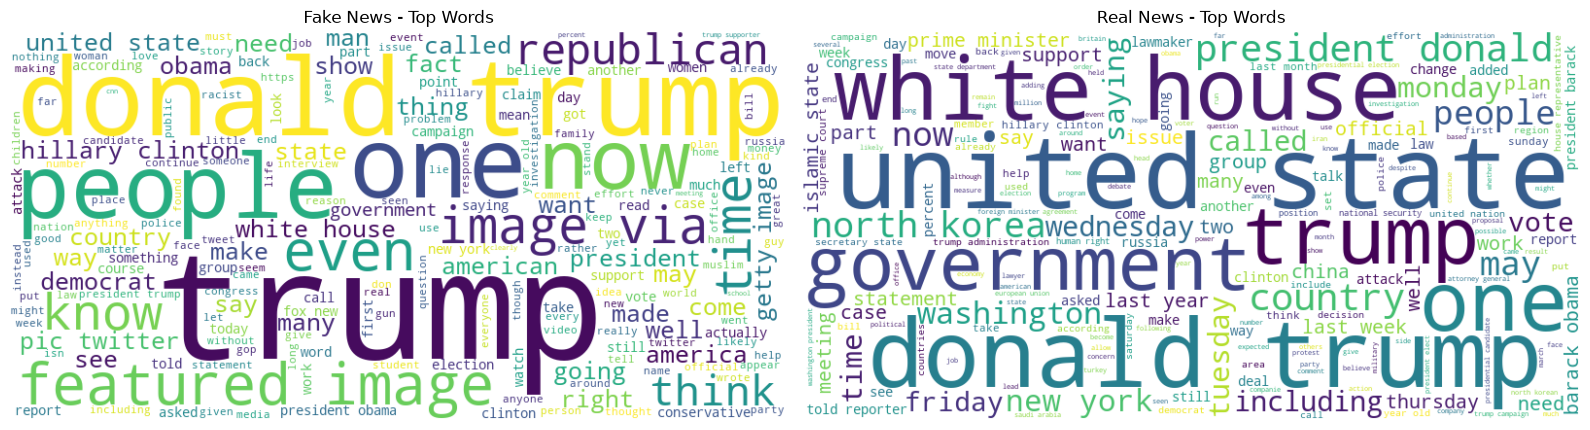

Top 20 fake words: [('trump', 68638), ('who', 31856), ('about', 25466), ('people', 21202), ('president', 20859), ('all', 20047), ('what', 19827), ('one', 18903), ('out', 18683), ('when', 17050), ('more', 16943), ('just', 16787), ('donald', 15396), ('there', 15373), ('him', 14731), ('our', 14678), ('like', 14374), ('clinton', 13554), ('obama', 13410), ('after', 13285)]
Top 20 real words: [('trump', 54075), ('president', 27857), ('who', 27305), ('state', 20781), ('which', 20527), ('after', 19135), ('government', 18550), ('about', 17268), ('more', 17038), ('new', 16735), ('house', 16462), ('states', 16412), ('republican', 16135), ('also', 15744), ('united', 15360), ('people', 15076), ('year', 14583), ('told', 14061), ('over', 13779), ('could', 13528)]


In [37]:
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# very lightweight stopword list just for this visualization step
stopwords = set([
    "the", "a", "an", "and", "or", "but", "is", "are", "was", "were",
    "in", "on", "at", "to", "of", "for", "with", "as", "by", "that",
    "this", "it", "its", "from", "he", "she", "they", "we", "you",
    "i", "his", "her", "their", "them", "be", "been", "has", "have",
    "had", "not", "will", "would", "said", "says", "will", "can",
    "reuters"  # excluded here on purpose so it doesn't drown the real-news cloud;
               # remove this line if you want to CONFIRM the leak visually first
])

def clean_for_wordcloud(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return words

fake_words = merged_news[merged_news['label'] == 0]['text'].apply(clean_for_wordcloud)
real_words = merged_news[merged_news['label'] == 1]['text'].apply(clean_for_wordcloud)

fake_flat = [w for row in fake_words for w in row]
real_flat = [w for row in real_words for w in row]

fake_wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(fake_flat))
real_wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(real_flat))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(fake_wc, interpolation='bilinear')
axes[0].set_title('Fake News - Top Words')
axes[0].axis('off')

axes[1].imshow(real_wc, interpolation='bilinear')
axes[1].set_title('Real News - Top Words')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../assets/wordcloud_fake_vs_real.png', dpi=150)
plt.show()

# also print top 20 words per class for a precise view
print("Top 20 fake words:", Counter(fake_flat).most_common(20))
print("Top 20 real words:", Counter(real_flat).most_common(20))

In [38]:
# check where "featured image" / "getty" typically appear in fake-news text

fake_with_image = merged_news[
    (merged_news['label'] == 0) &
    (merged_news['text'].str.contains('featured image|getty', case=False, na=False))
]

print(f"Rows matching: {fake_with_image.shape[0]}")

# print a few FULL raw text values, not truncated
for i, row in fake_with_image.sample(5, random_state=1).iterrows():
    print("=" * 80)
    print(row['text'])
    print()

Rows matching: 8670
Donald Trump claimed on Wednesday morning that he had  witnessed the horror and devastation  caused by Hurricane Harvey  first hand  during his visit to Texas earlier this week.After witnessing first hand the horror & devastation caused by Hurricane Harvey,my heart goes out even more so to the great people of Texas!  Donald J. Trump (@realDonaldTrump) August 30, 2017But just like everything out that comes out of Trump s mouth, this turned out to be just another one of his lies. When White House press secretary Sarah Huckabee Sanders was questioned about Trump s remark, she admitted that he was full of sh*t. He met with a number of local officials who are eating, sleeping, breathing the Harvey disaster,  Sanders said.  He talked extensively with the governor, who certainly is right in the midst of every bit of this, as well as the mayors from several of the local towns that were hit hardest. And detailed briefing information throughout the day yesterday talking to a 

In [39]:
merged_news.head()

,title,text,label,word_count
0,TOP 10 TWEETS From Democrat Debate,"Here s the fake black guy, Shaun King weighing...",0,349
1,Incredible Photo Of North Korean Soldier Secr...,While Trump s Secretary of State was visiting ...,0,423
2,Patrick Henningsen LIVE with guest Sean Stone ...,Join Patrick every week here at 21WIRE.TV for ...,0,165
3,Trump Just Bragged About The Size Of His Hand...,The size of Donald Trump s hands seems to be a...,0,372
4,Trump asks for probe into imports of foreign-m...,WASHINGTON (Reuters) - U.S. President Donald T...,1,265


In [40]:
merged_news.drop("word_count", axis=1, inplace=True)

In [41]:
merged_news.shape

(38483, 3)

In [43]:
merged_news.to_csv('../data/processed/merged_news.csv', index=False)